In [1]:
import os
import cooler
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import load_npz, save_npz, vstack, csr_matrix, triu
from scipy.stats import f, zscore, ranksums
from scipy.stats import norm, fisher_exact
from schicluster.cool.utilities import get_chrom_offsets
import itertools
from collections import Counter
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path
import joblib
import pyranges as pr
import matplotlib.pyplot as plt
from gprofiler import GProfiler
import seaborn as sns
import pyBigWig
from scipy.stats import pearsonr, zscore, norm
from pybedtools import BedTool

In [3]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 

In [4]:
bkl = pd.read_csv(
    '/home/hex002/scHiCluster/files/blacklist/hg38_m3C_loop_blacklist.bed.gz',
    sep='\t',
    header=None,
    names=[0,1,2]
)

In [5]:
geneRef = pd.read_csv('/cndd2/hex002/Luo_Development/genecode.v33.bed',names = ['chrom','start','end','strand','gene_id','gene_type','gene_name'],sep = '\t')
tss_df = geneRef.copy()

tss_df['TSS'] = np.where(
    tss_df['strand'] == '+',
    tss_df['start'],
    tss_df['end']
)

# Create ±2kb window
tss_df['win_start'] = tss_df['TSS'] - 2000
tss_df['win_end']   = tss_df['TSS'] + 2000

# Enforce non-negative genomic coordinates
tss_df['win_start'] = tss_df['win_start'].clip(lower=0)
tss_df = tss_df[tss_df['gene_type'] == 'protein_coding']
# Select final columns
tss_win = tss_df[['chrom','win_start','win_end','gene_id','gene_name','gene_type','strand','TSS']]
pr_tss = pr.PyRanges(
    tss_win.rename(columns={
        'chrom': 'Chromosome',
        'win_start': 'Start',
        'win_end': 'End'
    })
)


In [53]:
res = 10000
chrom_sizes = pd.read_csv(
    '/cndd2/hex002/Luo_Development/hg38/hg38.genome.sorted',
    sep='\t',
    header=None,
    index_col=[0])
    
autosomes = {f"chr{i}" for i in range(1, 23)}
chrom_sizes = chrom_sizes.loc[
    chrom_sizes.index.isin(autosomes)
].copy()

assert set(chrom_sizes.index) == autosomes

chrom_sizes_cool = cooler.read_chromsizes( '/cndd2/hex002/Luo_Development/hg38/hg38.genome.sorted', all_names=True)
bins_df = cooler.binnify(chrom_sizes_cool, res)
chrom_offset = get_chrom_offsets(bins_df)

In [10]:
def compute_anova(c, matrix,ctgroup,traj_name):
    # c, matrix = args
    ngene = int(chrom_sizes.loc[c] // res) + 1
    bkl_tmp = bkl.loc[(bkl[0]==c), [1,2]].values // res
    cov = np.zeros(ngene)
    for xx,yy in bkl_tmp:
        cov[xx-7:yy+7] = 1
    tot, last = 0, 0
    Esum, E2sum, Elast, E2last, ss_intra = [csr_matrix((ngene, ngene)) for i in range(5)]
    for ctlist in ctgroup:
        for ct in ctlist:
            cool_e = cooler.Cooler(f'{indir}/{ct}/{ct}/{ct}.{matrix}.cool')
            E = triu(cool_e.matrix(balance=False, sparse=True).fetch(c))
            cool_e2 = cooler.Cooler(f'{indir}/{ct}/{ct}/{ct}.{matrix}2.cool')
            E2 = triu(cool_e2.matrix(balance=False, sparse=True).fetch(c))
            n = cool_e.info['group_n_cells']
            Esum += E * n
            E2sum += E2 * n
            tot += n
            # print(c, ct)
        Egroup = Esum - Elast
        E2group = E2sum - E2last
        Egroup.data = Egroup.data ** 2 / (tot - last)
        ss_intra += (E2group - Egroup)
        Elast = Esum.copy()
        E2last = E2sum.copy()
        last = tot
    Esum.data = Esum.data ** 2 / tot
    ss_total = E2sum - Esum
    ss_intra.data = 1 / ss_intra.data
    ss_total = ss_total.multiply(ss_intra)
    # print(c, ss_total.data.min(), ss_intra.data.min())

    ss_total.data = (ss_total.data - 1) * (tot - len(ctgroup)) / (len(ctgroup) - 1)
    ss_total = ss_total.tocoo()
    bklfilter = np.logical_and(cov[ss_total.row]==0, cov[ss_total.col]==0)
    distfilter = np.logical_and((ss_total.col-ss_total.row)>5, (ss_total.col-ss_total.row)<500)
    idxfilter = np.logical_and(bklfilter, distfilter)
    # print(idxfilter.sum(), len(idxfilter))
    ss_total = csr_matrix((ss_total.data[idxfilter], (ss_total.row[idxfilter], ss_total.col[idxfilter])), (ngene, ngene))

    out_path = Path(outdir) / "diff" / traj_name
    out_path.mkdir(parents=True, exist_ok=True)

    save_npz(
        out_path / f"majortype_{matrix}pv_{c}.npz",
        ss_total
    )
    

    return [c, matrix, tot]

### Dev diff loop

In [61]:
target_trajectory = {
                'DRD1-EPHA4':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-EPHA4','3T_Inh-MSN-DRD1-EPHA4','1m_Inh-MSN-DRD1-EPHA4','4-7m_Inh-MSN-DRD1-EPHA4','adult_Inh-MSN-DRD1-EPHA4'],
               'DRD1-BACH2':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-BACH2','3T_Inh-MSN-DRD1-BACH2','1m_Inh-MSN-DRD1-BACH2','4-7m_Inh-MSN-DRD1-BACH2','adult_Inh-MSN-DRD1-BACH2'],
               'DRD2-EPHA4':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD2-EPHA4','3T_Inh-MSN-DRD2-EPHA4','1m_Inh-MSN-DRD2-EPHA4','4-7m_Inh-MSN-DRD2-EPHA4','adult_Inh-MSN-DRD2-EPHA4'],
               'DRD2-BACH2':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD2-BACH2','3T_Inh-MSN-DRD2-BACH2','1m_Inh-MSN-DRD2-BACH2','4-7m_Inh-MSN-DRD2-BACH2','adult_Inh-MSN-DRD2-BACH2'],
               'DRD1-eccentric':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-eccentric-CASZ1','3T_Inh-MSN-DRD1-eccentric-CASZ1','1m_Inh-MSN-DRD1-eccentric-CASZ1','4-7m_Inh-MSN-DRD1-eccentric-CASZ1','adult_Inh-MSN-DRD1-eccentric-CASZ1'],
                "CGE-VIP":   ["2T_Inh-CGE-eCGE","3T_Inh-CGE-VIP","1m_Inh-CGE-VIP","4-7m_Inh-CGE-VIP","adult_Inh-CGE-VIP"],
                "CGE-LAMP5": ["2T_Inh-CGE-eCGE","3T_Inh-CGE-LAMP5","1m_Inh-CGE-LAMP5","4-7m_Inh-CGE-LAMP5","adult_Inh-CGE-LAMP5"],
                "CGE-KCNJ1": ["2T_Inh-CGE-eCGE","3T_Inh-CGE-KCNJ1","1m_Inh-CGE-KCNJ1","4-7m_Inh-CGE-KCNJ1","adult_Inh-CGE-KCNJ1"],
                "MGE-PVALB":      ["2T_Inh-MGE-MGE","3T_Inh-MGE-PVALB","1m_Inh-MGE-PVALB","4-7m_Inh-MGE-PVALB","adult_Inh-MGE-PVALB"],
                "MGE-SST-NXPH2":  ["2T_Inh-MGE-MGE","3T_Inh-MGE-SST-NXPH2","1m_Inh-MGE-SST-NXPH2","4-7m_Inh-MGE-SST-NXPH2","adult_Inh-MGE-SST-NXPH2"],
                "MGE-SST-THRDE":  ["2T_Inh-MGE-MGE","3T_Inh-MGE-SST-THRDE","1m_Inh-MGE-SST-THRDE","4-7m_Inh-MGE-SST-THRDE","adult_Inh-MGE-SST-THRDE"],
                "Exc-UL-L1-3-CUX2": ["2T_Exc-RG-1-RG-1", "2T_Exc-UL-RG-UL","3T_Exc-UL-L1-3-CUX2", "1m_Exc-UL-L1-3-CUX2", "4-7m_Exc-UL-L1-3-CUX2","adult_Exc-UL-L1-3-CUX2"],
                "Exc-DL-ENT-CDH10": ["2T_Exc-RG-1-RG-1", "2T_Exc-DL-ENT-CDH10", "3T_Exc-DL-ENT-CDH10", "1m_Exc-DL-ENT-CDH10", "4-7m_Exc-DL-ENT-CDH10", "adult_Exc-DL-ENT-CDH10"],
                'Astro':['2T_Glial-Glial-RG','2T_Glial-Glial-Astro','3T_Glial-Glial-Astro','1m_Glial-Glial-Astro','4-7m_Glial-Glial-Astro','adult_Glial-Glial-Astro'],
                'OPC':['2T_Glial-Glial-RG','2T_Glial-Glial-OPC','3T_Glial-Glial-OPC','1m_Glial-Glial-OPC','4-7m_Glial-Glial-OPC','adult_Glial-Glial-OPC'],
                'ODC':['2T_Glial-Glial-RG','3T_Glial-Glial-ODC','1m_Glial-Glial-ODC','4-7m_Glial-Glial-ODC','adult_Glial-Glial-ODC'],
                'MGC-1':['2T_NN-NN-MGC-1','3T_NN-NN-MGC-1','1m_NN-NN-MGC-1','4-7m_NN-NN-MGC-1','adult_NN-NN-MGC-1'],
                'MGC-2':['3T_NN-NN-MGC-2','1m_NN-NN-MGC-2','4-7m_NN-NN-MGC-2','adult_NN-NN-MGC-2'],
            }

In [12]:
from concurrent.futures import ProcessPoolExecutor, as_completed

cpu = 10
matrices = ['Q', 'E', 'T']

In [ ]:
# dev = 'DRD2-BACH2'

In [59]:
indir = 'hic_loop/L3'
outdir = 'hic_loop/L3_MSN'

In [ ]:
for traj_name, traj_cts in target_trajectory.items():
    print(f'Running trajectory: {traj_name}')

    # each developmental stage = one ANOVA group
    ctgroup = [[ct] for ct in traj_cts]

    with ProcessPoolExecutor(cpu) as executor:
        futures = []

        for c in chrom_sizes.index:
            for m in matrices:
                future = executor.submit(
                    compute_anova,
                    c=c,
                    matrix=m,
                    ctgroup=ctgroup,
                    traj_name = traj_name
                )
                futures.append(future)

        for future in as_completed(futures):
            c1, m1, tot = future.result()
            print(f'{traj_name}: {c1} {m1} finished')

In [ ]:
from scipy.sparse import load_npz
import pandas as pd
import pathlib

def chrom_iterator_traj(
    input_dir,
    traj_name,
    matrix,
    chrom_order,
    chrom_offset,
    chunk_size=5_000_000
):
    """
    Stream ANOVA differential-contact pixels (per chromosome)
    into genome-wide bin coordinates for Cooler.
    """

    for chrom in chrom_order:
        npz_path = (
            f"{input_dir}/diff/{traj_name}/"
            f"majortype_{matrix}pv_{chrom}.npz"
        )

        if not pathlib.Path(npz_path).exists():
            continue

        data = load_npz(npz_path).tocoo()

        if data.nnz == 0:
            continue

        df = pd.DataFrame({
            "bin1_id": data.row,
            "bin2_id": data.col,
            "count":  data.data
        })

        # upper triangle only (Cooler requirement)
        df = df[df["bin1_id"] <= df["bin2_id"]]

        # stream in chunks
        for start in range(0, df.shape[0], chunk_size):
            chunk = df.iloc[start:start + chunk_size].copy()
            chunk.iloc[:, :2] += chrom_offset[chrom]
            yield chunk

In [ ]:
cpu = 6
def build_one_cool(args):
    traj_name, matrix, outdir, bins_df, chrom_order, chrom_offset = args

    output_prefix = f"{outdir}/diff/{traj_name}/{matrix}pv"
    cool_path = f"{output_prefix}.cool"

    cooler.create_cooler(
        cool_uri=cool_path,
        bins=bins_df,
        pixels=chrom_iterator_traj(
            input_dir=outdir,
            traj_name=traj_name,
            matrix=matrix,
            chrom_order=chrom_order,
            chrom_offset=chrom_offset
        ),
        ordered=True,
        dtypes={"count": np.float32}
    )

    return traj_name, matrix, cool_path

In [ ]:
cpu = 9  
tasks = [
    (traj_name, matrix, outdir, bins_df, chrom_sizes.index, chrom_offset)
    for traj_name in target_trajectory.keys()
    for matrix in ["Q", "E", "T"]
]

with ProcessPoolExecutor(max_workers=cpu) as ex:
    futures = [ex.submit(build_one_cool, t) for t in tasks]

    for f in as_completed(futures):
        traj_name, matrix, cool_path = f.result()
        print(f"Done: {traj_name} {matrix} -> {cool_path}")

In [ ]:
for traj_name in target_trajectory.keys():
    traj_dir = Path(outdir) / "diff" / traj_name
    for p in traj_dir.glob("*pv_*chr*.npz"):
        p.unlink()

### Exam Diff loop

In [33]:
def process_one_trajectory(dev_leg):
    leg = target_trajectory[dev_leg]

    # ---- load & merge loops across stages ----
    loopall = []
    for ct_age in leg:
        path = f'{indir}/{ct_age}/{ct_age}/{ct_age}.loop.bedpe'
        df = pd.read_csv(path, sep='\t', header=None)
        loopall.append(df)

    loopall = pd.concat(loopall, axis=0, ignore_index=True)

    # keep chr1, start1, chr2, start2, etc.
    loopall = (
        loopall
        .drop(columns=[6])
        .drop_duplicates(subset=[0, 1, 4])
        .sort_values([0, 1, 4])
    )

    
    chroms = chrom_sizes.index
    loopall = loopall[loopall[0].isin(chroms)].copy()
    loopall.reset_index(drop=True, inplace=True)

    # initialize columns
    for matrix in ['Q', 'E', 'T']:
        loopall[f'{matrix}anova'] = np.nan

    # ---- per chromosome extraction ----
    for c in chroms:
        loopfilter = loopall[0] == c
        if loopfilter.sum() == 0:
            continue

        # bin loop anchors
        looptmp = loopall.loc[loopfilter, [1, 4]].values // res

        for matrix in ['Q', 'E', 'T']:
            cool_path = f'{outdir}/diff/{dev_leg}/{matrix}pv.cool'
            clr = cooler.Cooler(cool_path)

            pv = triu(
                clr.matrix(balance=False, sparse=True).fetch(c)
            ).tocsr()

            loopall.loc[loopfilter, f'{matrix}anova'] = (
                pv[(looptmp[:, 0], looptmp[:, 1])].A1
            )

    # ---- save per-trajectory output ----
    out_path = f'{outdir}/diff/{dev_leg}/merged_loop.hdf'
    loopall.to_hdf(out_path, key='data', mode='w')

    return dev_leg, loopall.shape[0]

In [39]:
results = []

with ProcessPoolExecutor(max_workers=5) as executor:
    futures = [
        executor.submit(process_one_trajectory, dev_leg)
        for dev_leg in target_trajectory.keys()
    ]

    for f in as_completed(futures):
        dev_leg, nloop = f.result()
        print(f'{dev_leg}: {nloop} loops processed')

/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->axis0] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->integer,key->block1_items] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->integer,key->block2_items] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixe

DRD1-BACH2: 616798 loops processed


/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->integer,key->block1_items] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->integer,key->block2_items] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->axis0] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->inte

DRD2-EPHA4: 447611 loops processed
DRD1-EPHA4: 462095 loops processed


/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->axis0] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->integer,key->block1_items] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->integer,key->block2_items] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')


DRD1-eccentric: 568654 loops processed


/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->axis0] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->integer,key->block1_items] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')
/tmp/ipykernel_304682/2240955090.py:53: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->integer,key->block2_items] [items->None]

  loopall.to_hdf(out_path, key='data', mode='w')


DRD2-BACH2: 613236 loops processed


## Test individual dev trajector

In [42]:
def load_Q(ct_age, m):
    values = np.full(len(loopall), np.nan)

    matrix = cooler.Cooler(
        f"{indir}/{ct_age}/{ct_age}/{ct_age}.{m}.cool"
    ).matrix(balance=False, sparse=True)

    for chrom in loopall[0].unique():
        rows = np.flatnonzero(loopall[0].eq(chrom).to_numpy())
        anchors = (
            loopall.iloc[rows][[1, 4]].to_numpy(dtype=int) // 10000
        )

        mat = matrix.fetch(chrom).tocsr()

        # Preserve each loop's position in merged_loop.hdf
        values[rows] = mat[anchors[:, 0], anchors[:, 1]].A1

    return [ct_age, values]

In [56]:
def run_one_matrix(dev, m, cpu=10):
    """
    For one trajectory and one matrix (Q or T),
    load loop values across all stages in parallel
    and return a DataFrame with columns ordered by leg.
    """
    leg = target_trajectory[dev]

    loop_dfs = []

    with ProcessPoolExecutor(max_workers=cpu) as executor:
        futures = [
            executor.submit(load_Q, ct_age=xx, m=m)
            for xx in leg
        ]

        for future in as_completed(futures):
            ct_age, vals = future.result()
            loop_dfs.append(pd.DataFrame(vals, columns=[ct_age]))
            print(f'{dev} {m} {ct_age} finished')

    df = pd.concat(loop_dfs, axis=1)

    # enforce developmental order
    df = df[leg]

    return df

In [60]:
base_dir = '/cndd5/hex002/Luo_Dev/hic_loop/L3_MSN/diff'

for dev in target_trajectory.keys():
    print(f'Processing trajectory: {dev}')

    # sanity check: merged loop table exists
    merged_path = f'{base_dir}/{dev}/merged_loop.hdf'
    loopall = pd.read_hdf(merged_path, key='data')

    # ---- Q matrix ----
    loopq = run_one_matrix(dev, m='Q', cpu=cpu)
    loopq.to_hdf(f'{base_dir}/{dev}/loop_Q.hdf', key='data', mode='w')

    # ---- T matrix ----
    loopt = run_one_matrix(dev, m='T', cpu=cpu)
    loopt.to_hdf(f'{base_dir}/{dev}/loop_T.hdf', key='data', mode='w')

Processing trajectory: CGE-VIP
CGE-VIP Q 4-7m_Inh-CGE-VIP finished
CGE-VIP Q 3T_Inh-CGE-VIP finished
CGE-VIP Q adult_Inh-CGE-VIP finished
CGE-VIP Q 1m_Inh-CGE-VIP finished
CGE-VIP Q 2T_Inh-CGE-eCGE finished
CGE-VIP T 3T_Inh-CGE-VIP finished
CGE-VIP T 2T_Inh-CGE-eCGE finished
CGE-VIP T 1m_Inh-CGE-VIP finished
CGE-VIP T 4-7m_Inh-CGE-VIP finished
CGE-VIP T adult_Inh-CGE-VIP finished
Processing trajectory: CGE-LAMP5
CGE-LAMP5 Q 2T_Inh-CGE-eCGE finished
CGE-LAMP5 Q 1m_Inh-CGE-LAMP5 finished
CGE-LAMP5 Q 3T_Inh-CGE-LAMP5 finished
CGE-LAMP5 Q 4-7m_Inh-CGE-LAMP5 finished
CGE-LAMP5 Q adult_Inh-CGE-LAMP5 finished
CGE-LAMP5 T 2T_Inh-CGE-eCGE finished
CGE-LAMP5 T 3T_Inh-CGE-LAMP5 finished
CGE-LAMP5 T 1m_Inh-CGE-LAMP5 finished
CGE-LAMP5 T 4-7m_Inh-CGE-LAMP5 finished
CGE-LAMP5 T adult_Inh-CGE-LAMP5 finished
Processing trajectory: CGE-KCNJ1
CGE-KCNJ1 Q 2T_Inh-CGE-eCGE finished
CGE-KCNJ1 Q 1m_Inh-CGE-KCNJ1 finished
CGE-KCNJ1 Q 3T_Inh-CGE-KCNJ1 finished
CGE-KCNJ1 Q adult_Inh-CGE-KCNJ1 finished
CGE-KCNJ1

In [44]:
def map_stage(ct_age):
    if '2T_Inh-MSN-eMSN' in ct_age:
        return '2T_eMSN'
    elif ct_age.startswith('2T_'):
        return '2T_subtype'
    elif ct_age.startswith('3T_'):
        return '3T'
    elif ct_age.startswith('1m_'):
        return '1m'
    elif ct_age.startswith('4-7m_'):
        return '4-7m'
    elif ct_age.startswith('adult_'):
        return 'adult'
    else:
        raise ValueError(ct_age)

In [46]:
stage_order = [
    '2T_eMSN',
    '2T_subtype',
    '3T',
    '1m',
    '4-7m',
    'adult'
]

In [48]:
from scipy.stats import zscore

thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
rows = []

for dev, leg in target_trajectory.items():

    if "DRD" not in dev:
        continue

    print(f"Processing {dev}")

    loopq = pd.read_hdf(f"{outdir}/diff/{dev}/loop_Q.hdf", key="data")
    loopall = pd.read_hdf(f"{outdir}/diff/{dev}/merged_loop.hdf", key="data")

    selb = (
        (zscore(loopall["Qanova"]) > thres1) &
        (zscore(loopall["Tanova"]) > thres2)
    )

    if selb.sum() == 0:
        print(f"  ⚠ No dev-diff loops for {dev}")
        continue

    loopq_sel = loopq.loc[selb]

    # z-score per loop
    loopq_z = pd.DataFrame(
        zscore(loopq_sel, axis=1),
        index=loopq_sel.index,
        columns=loopq_sel.columns
    )

    stage_vals = {}

    for stage in stage_order:
        cols = [c for c in loopq_z.columns if map_stage(c) == stage]

        if len(cols) == 0:
            stage_vals[stage] = np.nan
        else:
            stage_vals[stage] = np.nanmedian(loopq_z[cols].values)

    stage_vals["dev"] = dev
    rows.append(stage_vals)

# --------------------------
# Final table
# --------------------------
if len(rows) == 0:
    raise ValueError("No valid rows collected — check MSN filter or inputs.")

heat_df = (
    pd.DataFrame(rows)
    .set_index("dev")
    # .loc[list(target_trajectory.keys()), stage_order]
)

Processing DRD1-EPHA4
Processing DRD1-BACH2
Processing DRD2-EPHA4
Processing DRD2-BACH2
Processing DRD1-eccentric


In [49]:
heat_df.index = heat_df.index.str.replace('EPHA4','Matrix')
heat_df.index = heat_df.index.str.replace('BACH2','Striosome')

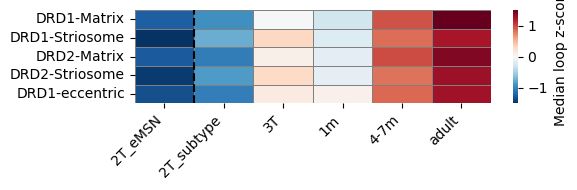

In [96]:
plt.figure(figsize=(6, 2))

ax = sns.heatmap(
    heat_df,
    cmap='RdBu_r',
    center=0,
    vmin=-1.5, vmax=1.5,   # tighten after inspection
    linewidths=0.5,
    linecolor='gray',
    cbar_kws=dict(label='Median loop z-score')
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# prenatal/postnatal boundary
boundary = heat_df.columns.get_loc("3T") + 1
ax.axvline(boundary, color="black", lw=1.5, ls="--")

plt.savefig('MSN_loop_strength.pdf')
plt.tight_layout()
plt.show()

## Function annotation

In [54]:
def loops_to_anchors(loop_df):
    """
    Build PyRanges of loop anchors from merged_loop.hdf
    using columns:
    [0,1,2] and [3,4,5]
    """
    a1 = loop_df[[0, 1, 2]].copy()
    a1.columns = ['Chromosome', 'Start', 'End']

    a2 = loop_df[[3, 4, 5]].copy()
    a2.columns = ['Chromosome', 'Start', 'End']

    anchors = (
        pd.concat([a1, a2], axis=0)
        .drop_duplicates()
        .reset_index(drop=True)
    )

    return pr.PyRanges(anchors)

In [55]:
def standardize_loop_df(loop_df):
    df = loop_df.copy()
    df = df.rename(columns={
        0: "chrom1",
        1: "start1",
        2: "end1",
        3: "chrom2",
        4: "start2",
        5: "end2",
    })
    return df

In [78]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm, zscore

eps = 1e-6
thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)

q_fc_threshold = np.log2(1.2)
t_delta_threshold = 0.0  # T provides directional support

results = {}
summary_rows = []


def get_promoter_genes(loop_df):
    """Return unique promoter-overlapping genes; handle empty loops."""
    gene_cols = ["gene_id", "gene_name"]

    if loop_df.empty:
        return pd.DataFrame(columns=gene_cols)

    anchors = loops_to_anchors(loop_df)
    hits = pr_tss.join(anchors)

    if hits.df.empty:
        return pd.DataFrame(columns=gene_cols)

    return (
        hits.df[gene_cols]
        .drop_duplicates()
        .reset_index(drop=True)
    )


for dev, leg in target_trajectory.items():
    print(f"\nProcessing {dev}")

    # --------------------------------------------------
    # Load data
    # --------------------------------------------------
    traj_dir = Path(outdir) / "diff" / dev

    loopall = pd.read_hdf(traj_dir / "merged_loop.hdf", key="data")
    loopq = pd.read_hdf(traj_dir / "loop_Q.hdf", key="data")
    loopt = pd.read_hdf(traj_dir / "loop_T.hdf", key="data")

    if len(leg) < 2:
        raise ValueError(f"{dev}: at least two groups are required.")

    if loopall.empty:
        raise ValueError(f"{dev}: merged_loop.hdf is empty.")

    # Structural checks cannot detect an old chromosome-order mismatch.
    # Use Q/T tables generated with the corrected load_Q().
    for name, table in [("Q", loopq), ("T", loopt)]:
        if not table.index.equals(loopall.index):
            raise ValueError(
                f"{dev}: {name} table index does not match merged loops."
            )
        if not table.index.is_unique:
            raise ValueError(f"{dev}: duplicate indices in {name} table.")

        missing = [ct for ct in leg if ct not in table.columns]
        if missing:
            raise ValueError(f"{dev}: missing {name} groups: {missing}")

    scores = loopall[["Qanova", "Tanova"]].to_numpy(dtype=float)
    if not np.isfinite(scores).all():
        raise ValueError(
            f"{dev}: ANOVA scores contain NaN or infinity; "
            "inspect these before standardization."
        )

    # --------------------------------------------------
    # Step 1: Developmental differential loops
    # Keep the existing ANOVA selection rule.
    # --------------------------------------------------
    selb = pd.Series(
        (zscore(loopall["Qanova"].to_numpy()) > thres1)
        & (zscore(loopall["Tanova"].to_numpy()) > thres2),
        index=loopall.index,
    )

    loops_diff = loopall.loc[selb].copy()

    # --------------------------------------------------
    # Step 2: First-to-last endpoint changes
    # Keep the original trajectory endpoints.
    # --------------------------------------------------
    first_ct = leg[0]
    last_ct = leg[-1]

    q_first = loopq.loc[selb, first_ct]
    q_last = loopq.loc[selb, last_ct]
    t_first = loopt.loc[selb, first_ct]
    t_last = loopt.loc[selb, last_ct]

    valid = (
        np.isfinite(q_first)
        & np.isfinite(q_last)
        & np.isfinite(t_first)
        & np.isfinite(t_last)
        & (q_first >= 0)
        & (q_last >= 0)
    )

    fcQ = pd.Series(
        np.nan, index=loops_diff.index, name="log2FC_Q"
    )
    fcQ.loc[valid] = np.log2(
        (q_last.loc[valid] + eps)
        / (q_first.loc[valid] + eps)
    )

    # T is compared by difference, allowing negative values
    # and changes across zero.
    deltaT = (t_last - t_first).rename("delta_T")

    valid = valid & np.isfinite(fcQ) & np.isfinite(deltaT)

    # --------------------------------------------------
    # Step 3: Gain/loss classification
    # --------------------------------------------------
    gain_idx = (
        valid
        & (fcQ > q_fc_threshold)
        & (deltaT > t_delta_threshold)
    )

    loss_idx = (
        valid
        & (fcQ < -q_fc_threshold)
        & (deltaT < -t_delta_threshold)
    )

    other_idx = valid & ~(gain_idx | loss_idx)
    invalid_idx = ~valid

    loops_gain = loops_diff.loc[gain_idx].copy()
    loops_loss = loops_diff.loc[loss_idx].copy()
    loops_other = loops_diff.loc[other_idx].copy()
    loops_invalid = loops_diff.loc[invalid_idx].copy()

    # Retain endpoint measurements and classification for inspection.
    endpoint_stats = pd.DataFrame({
        "Q_first": q_first,
        "Q_last": q_last,
        "T_first": t_first,
        "T_last": t_last,
        "log2FC_Q": fcQ,
        "delta_T": deltaT,
        "valid": valid,
    })

    endpoint_stats["classification"] = "other"
    endpoint_stats.loc[gain_idx, "classification"] = "gain"
    endpoint_stats.loc[loss_idx, "classification"] = "loss"
    endpoint_stats.loc[invalid_idx, "classification"] = "invalid"

    # --------------------------------------------------
    # Steps 4–6: Anchor/promoter overlaps and gene lists
    # Background uses all merged candidate loops.
    # --------------------------------------------------
    genes_gain = get_promoter_genes(loops_gain)
    genes_loss = get_promoter_genes(loops_loss)
    genes_bg = get_promoter_genes(loopall)

    print(f"  endpoints: {first_ct} -> {last_ct}")
    print(f"  dev-diff loops: {len(loops_diff)}")
    print(
        f"  gain: {len(loops_gain)}, "
        f"loss: {len(loops_loss)}, "
        f"other: {len(loops_other)}, "
        f"invalid: {len(loops_invalid)}"
    )
    print(
        f"  gain genes: {len(genes_gain)}, "
        f"loss genes: {len(genes_loss)}, "
        f"background genes: {len(genes_bg)}"
    )

    # --------------------------------------------------
    # Store results in memory
    # --------------------------------------------------
    results[dev] = {
        "loops_diff": loops_diff,
        "loops_gain": loops_gain,
        "loops_loss": loops_loss,
        "loops_other": loops_other,
        "loops_invalid": loops_invalid,
        "genes_gain": genes_gain,
        "genes_loss": genes_loss,
        "genes_bg": genes_bg,
        "endpoint_stats": endpoint_stats,
        "first_ct": first_ct,
        "last_ct": last_ct,
    }

    summary_rows.append({
        "dev": dev,
        "n_dev_diff_loops": len(loops_diff),
        "n_gain_loops": len(loops_gain),
        "n_loss_loops": len(loops_loss),
        "n_other_loops": len(loops_other),
        "n_invalid_loops": len(loops_invalid),
        "n_gain_genes": len(genes_gain),
        "n_loss_genes": len(genes_loss),
        "n_background_genes": len(genes_bg),
    })

summary_df = pd.DataFrame(summary_rows).set_index("dev")
summary_df


Processing DRD1-EPHA4
  endpoints: 2T_Inh-MSN-eMSN -> adult_Inh-MSN-DRD1-EPHA4
  dev-diff loops: 11226
  gain: 11219, loss: 0, other: 7, invalid: 0
  gain genes: 1653, loss genes: 0, background genes: 12594

Processing DRD1-BACH2
  endpoints: 2T_Inh-MSN-eMSN -> adult_Inh-MSN-DRD1-BACH2
  dev-diff loops: 13805
  gain: 13754, loss: 0, other: 51, invalid: 0
  gain genes: 2097, loss genes: 0, background genes: 13169

Processing DRD2-EPHA4
  endpoints: 2T_Inh-MSN-eMSN -> adult_Inh-MSN-DRD2-EPHA4
  dev-diff loops: 11228
  gain: 11220, loss: 1, other: 7, invalid: 0
  gain genes: 1679, loss genes: 0, background genes: 12307

Processing DRD2-BACH2
  endpoints: 2T_Inh-MSN-eMSN -> adult_Inh-MSN-DRD2-BACH2
  dev-diff loops: 13851
  gain: 13832, loss: 0, other: 19, invalid: 0
  gain genes: 2140, loss genes: 0, background genes: 13540

Processing DRD1-eccentric
  endpoints: 2T_Inh-MSN-eMSN -> adult_Inh-MSN-DRD1-eccentric-CASZ1
  dev-diff loops: 12781
  gain: 12731, loss: 0, other: 50, invalid: 0
  

,n_dev_diff_loops,n_gain_loops,n_loss_loops,n_other_loops,n_invalid_loops,n_gain_genes,n_loss_genes,n_background_genes
dev,,,,,,,,
DRD1-EPHA4,11226,11219,0,7,0,1653,0,12594
DRD1-BACH2,13805,13754,0,51,0,2097,0,13169
DRD2-EPHA4,11228,11220,1,7,0,1679,0,12307
DRD2-BACH2,13851,13832,0,19,0,2140,0,13540
DRD1-eccentric,12781,12731,0,50,0,1982,0,12771
CGE-VIP,14443,14443,0,0,0,2310,0,12490
CGE-LAMP5,16645,16645,0,0,0,2405,0,12977
CGE-KCNJ1,11856,11856,0,0,0,2000,0,11598
MGE-PVALB,13977,13974,3,0,0,2111,1,12817


In [88]:
from matplotlib.ticker import FixedLocator, LogFormatterMathtext

/tmp/ipykernel_304682/2023240484.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(


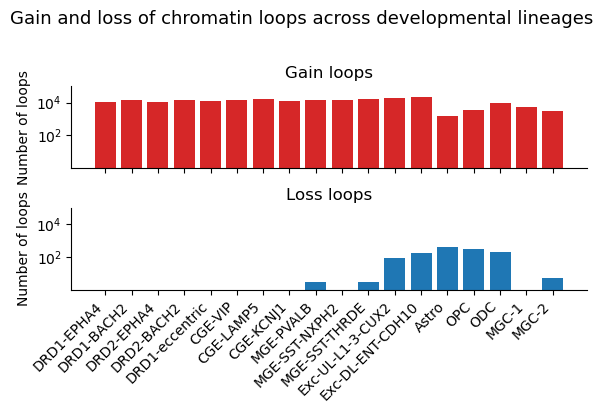

In [94]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(6, 4),
    sharex=True,
    sharey=True
)

# -------------------
# Gain loops
# -------------------
axes[0].bar(
    summary_df.index,
    summary_df['n_gain_loops'],
    color='#d62728'
)
axes[0].set_title('Gain loops', fontsize=12)
axes[0].set_ylabel('Number of loops')
axes[0].set_yscale('log')
axes[0].set_ylim(1, 1e5)  # Adjust upper limit as needed
axes[0].yaxis.set_major_locator(FixedLocator([1e2, 1e4]))
axes[0].yaxis.set_major_formatter(LogFormatterMathtext())
# -------------------
# Loss loops
# -------------------
axes[1].bar(
    summary_df.index,
    summary_df['n_loss_loops'],
    color='#1f77b4'
)
axes[1].set_title('Loss loops', fontsize=12)
axes[1].set_ylabel('Number of loops')
axes[1].set_yscale('log')
axes[1].set_ylim(1, 1e5)  # Adjust upper limit as needed
axes[1].yaxis.set_major_locator(FixedLocator([1e2, 1e4]))
axes[1].yaxis.set_major_formatter(LogFormatterMathtext())
# -------------------
# Formatting
# -------------------
axes[1].set_xticklabels(
    summary_df.index,
    rotation=45,
    ha='right'
)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Gain and loss of chromatin loops across developmental lineages',
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.savefig('diff_loops_count.pdf')
plt.show()

In [82]:
go_dir = f"{outdir}/GO"
os.makedirs(go_dir, exist_ok=True)
gp = GProfiler(return_dataframe=True)

go_tables = {}

for dev in results:

    print(f"\n{dev}")

    go_tables[dev] = {}

    # ------------------
    # GAIN genes
    # ------------------
    genes_gain = (
        results[dev]['genes_gain']['gene_name']
        .dropna()
        .unique()
        .tolist()
    )

    print("  gain genes:", len(genes_gain))

    if len(genes_gain) >= 10:
        gost_gain = gp.profile(
            organism='hsapiens',
            query=genes_gain,
            sources=['GO:BP'],
            user_threshold=0.05,
            significance_threshold_method='fdr',
            no_evidences=False
        )

        gost_gain = gost_gain[gost_gain['source'] == 'GO:BP'].copy()

        gost_gain.to_csv(
            f"{go_dir}/{dev}_GO_BP_gain.tsv",
            sep="\t",
            index=False
        )

        go_tables[dev]['gain'] = gost_gain
    else:
        go_tables[dev]['gain'] = None

    # ------------------
    # LOSS genes
    # ------------------
    genes_loss = (
        results[dev]['genes_loss']['gene_name']
        .dropna()
        .unique()
        .tolist()
    )

    print("  loss genes:", len(genes_loss))

    if len(genes_loss) >= 10:
        gost_loss = gp.profile(
            organism='hsapiens',
            query=genes_loss,
            sources=['GO:BP'],
            user_threshold=0.05,
            significance_threshold_method='fdr',
            no_evidences=False
        )

        gost_loss = gost_loss[gost_loss['source'] == 'GO:BP'].copy()

        gost_loss.to_csv(
            f"{go_dir}/{dev}_GO_BP_loss.tsv",
            sep="\t",
            index=False
        )

        go_tables[dev]['loss'] = gost_loss
    else:
        go_tables[dev]['loss'] = None


DRD1-EPHA4
  gain genes: 1652
  loss genes: 0

DRD1-BACH2
  gain genes: 2096
  loss genes: 0

DRD2-EPHA4
  gain genes: 1678
  loss genes: 0

DRD2-BACH2
  gain genes: 2140
  loss genes: 0

DRD1-eccentric
  gain genes: 1981
  loss genes: 0

CGE-VIP
  gain genes: 2308
  loss genes: 0

CGE-LAMP5
  gain genes: 2403
  loss genes: 0

CGE-KCNJ1
  gain genes: 1998
  loss genes: 0

MGE-PVALB
  gain genes: 2109
  loss genes: 1

MGE-SST-NXPH2
  gain genes: 2290
  loss genes: 0

MGE-SST-THRDE
  gain genes: 2184
  loss genes: 0

Exc-UL-L1-3-CUX2
  gain genes: 2296
  loss genes: 8

Exc-DL-ENT-CDH10
  gain genes: 2452
  loss genes: 9

Astro
  gain genes: 669
  loss genes: 31

OPC
  gain genes: 872
  loss genes: 39

ODC
  gain genes: 1738
  loss genes: 26

MGC-1
  gain genes: 1201
  loss genes: 0

MGC-2
  gain genes: 825
  loss genes: 2


In [83]:
top_go = {'gain': {}, 'loss': {}}
MIN_TERM_SIZE = 20
MAX_TERM_SIZE = 1200

top_go = {'gain': {}, 'loss': {}}

for dev in go_tables:
    for mode in ['gain', 'loss']:

        df = go_tables[dev].get(mode)
        if df is None or df.empty:
            continue

        df = df.copy()

        # Filter by GO term size
        df = df[
            (df['term_size'] >= MIN_TERM_SIZE) &
            (df['term_size'] <= MAX_TERM_SIZE)
        ]

        # Compute significance
        df['neglog10_fdr'] = -np.log10(df['p_value'])

        # Select top terms
        top_go[mode][dev] = (
            df.sort_values('p_value')
              .head(5)
        )

In [85]:
plot_df = {}

for mode in ['gain', 'loss']:

    plot_rows = []

    for dev, df in top_go[mode].items():
        tmp = df.copy()
        tmp['dev'] = dev
        plot_rows.append(tmp)

    plot_df[mode] = pd.concat(
        plot_rows,
        axis=0,
        ignore_index=True
    )

go_order = {}

for mode in ['gain', 'loss']:

    go_order[mode] = (
        plot_df[mode]
        .groupby('name')['neglog10_fdr']
        .max()
        .sort_values(ascending=False)
        .index
    )

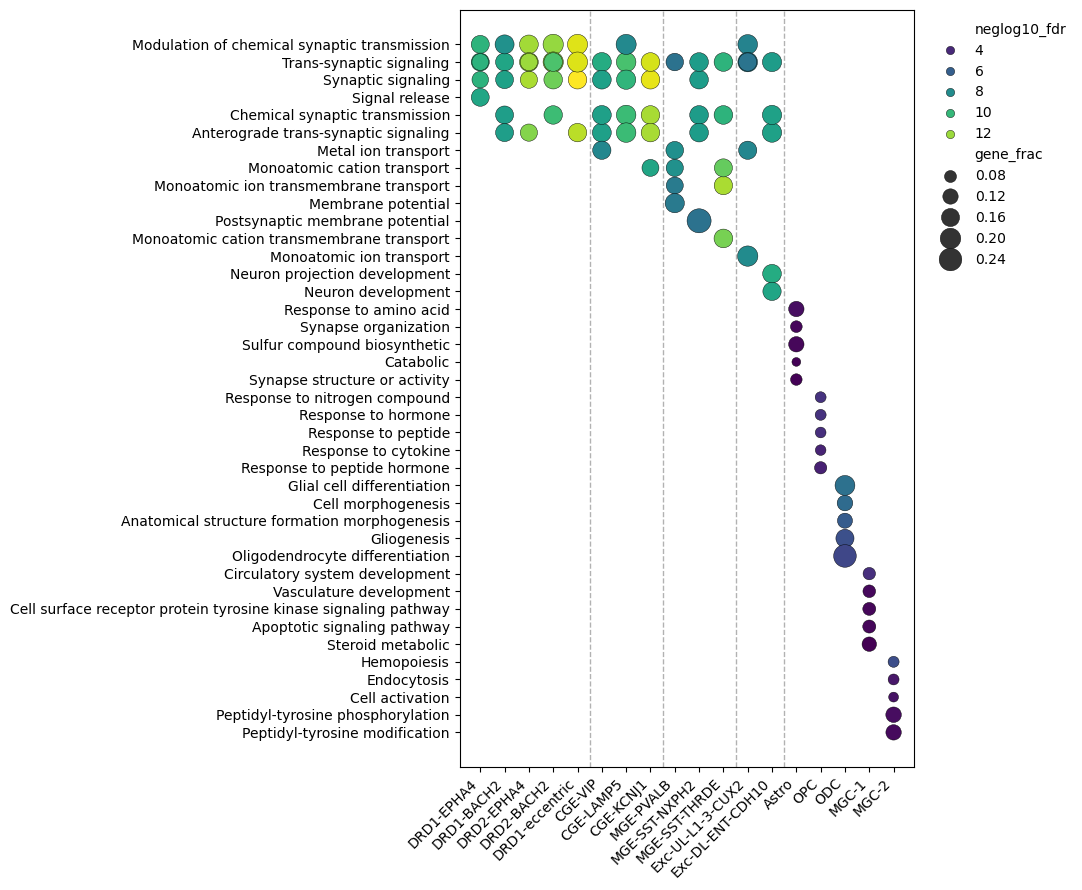

In [95]:
# -----------------------------
# Filter + prepare data
# -----------------------------

df = plot_df['gain'].copy()
df = df[df['term_size'] <= MAX_TERM_SIZE]
def clean_go_name(name):
    replacements = {
        'regulation of ': '',
        'positive regulation of ': '',
        'negative regulation of ': '',
        'cellular ': '',
        'process': '',
        'biological process': '',
        'involved in ': '',
    }
    for k, v in replacements.items():
        name = name.replace(k, v)
    return name.strip().capitalize()

# Fraction of genes involved
df['gene_frac'] = df['intersection_size'] / df['term_size']
df['name_clean'] = df['name'].apply(clean_go_name)

# Define biological order of cell types
dev_order = [
    'DRD1-EPHA4','DRD1-BACH2',
    'DRD2-EPHA4','DRD2-BACH2',
    'DRD1-eccentric',
    'CGE-VIP','CGE-LAMP5','CGE-KCNJ1',
    'MGE-PVALB','MGE-SST-NXPH2','MGE-SST-THRDE',
    'Exc-UL-L1-3-CUX2','Exc-DL-ENT-CDH10',
    'Astro','OPC','ODC','MGC-1','MGC-2'
]

df['dev'] = pd.Categorical(df['dev'], categories=dev_order, ordered=True)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(11, 9))

ax = sns.scatterplot(
    data=df,
    x='dev',
    y='name_clean',
    size='gene_frac',
    hue='neglog10_fdr',
    sizes=(40, 300),
    palette='viridis',
    edgecolor='black',
    linewidth=0.3
)

# -----------------------------
# Labels & formatting
# -----------------------------
ax.set_title(
    '',
    fontsize=14,
    pad=12
)

ax.set_xlabel('', fontsize=11)
ax.set_ylabel('', fontsize=11)

plt.xticks(rotation=45, ha='right')
boundaries = [5, 8, 11, 13]

for b in boundaries:
    plt.axvline(
        x=b - 0.5,
        color='gray',
        linestyle='--',
        linewidth=1,
        alpha=0.6
    )
# Improve legend readability
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles=handles,
    labels=labels,
    title="",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.savefig('Loop_gene_enrichemnt.pdf')
plt.show()
